# Version requirements

* python version: 3.11
* imageio: 2.33
* opencv: 4.8

In [1]:
# Please uncomment the below line to install imageio library
# !pip install imageio

In [2]:
import urllib.request

from IPython.display import display, Image
import imageio.v2 as imageio
import os
import cv2

import numpy as np
import glob
import PIL
import matplotlib.pyplot as plt

# Image as numpy array

Creating a 5 row, 3 column numpy array

In [3]:
arr1 = np.ones((5,3))
arr1

array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]])

Image is nothing but pixel brightness values ranging from 0 to 255

In [4]:
arr1 = arr1*255
arr1

array([[255., 255., 255.],
       [255., 255., 255.],
       [255., 255., 255.],
       [255., 255., 255.],
       [255., 255., 255.]])

Making the array look like the digit three

In [5]:
arr1[1, :2]=0
arr1[3, :2]=0

In [6]:
arr1

array([[255., 255., 255.],
       [  0.,   0., 255.],
       [255., 255., 255.],
       [  0.,   0., 255.],
       [255., 255., 255.]])

**visualizing the digit**

In [7]:
# !pip install opencv-python
# !pip install opencv-contrib-python

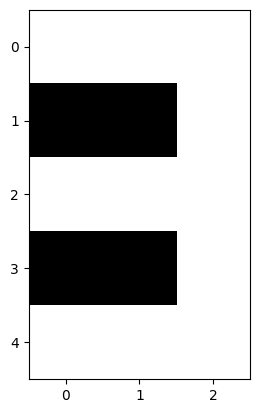

In [8]:
plt.imshow(arr1, cmap="gray");

In [9]:
arr1

array([[255., 255., 255.],
       [  0.,   0., 255.],
       [255., 255., 255.],
       [  0.,   0., 255.],
       [255., 255., 255.]])

This is what the computer sees. Even if we reshape the image to 1 dimension, it still is the same image, we can convert it back to original row, column dimension

In [10]:
arr1.reshape(-1)

array([255., 255., 255.,   0.,   0., 255., 255., 255., 255.,   0.,   0.,
       255., 255., 255., 255.])

## Visualizing sample image from directory

I keep all my images, videos, or resources that I want to use as data in a separate `resources` folder

We already have created a resources folder and downloaded the sample image there, but if for some reason the image was not downloaded, we will use the following logic to handle potential errors.

If the folder exists for you, we'll display the image, otherwise we will use github repo to visualize that image

This is how my directory looks like

In [11]:
os.listdir()

['7 - imdb_eda.ipynb',
 '7.3 - model analysis.py',
 '2 - opencv image on image.ipynb',
 'resources',
 '6 - alexa_improved_nlp_pipeline.ipynb',
 '7.2 - train_imdb_model.py',
 '5 - embedding vectors basics.ipynb',
 '1 - Image manipulation opencv.ipynb',
 '4 - regular_expressions_beautified.ipynb',
 '3 - Image thresholding.ipynb']

In [12]:
# This is our current working directory as CLI path
os.getcwd()

'/root/14daybootcamp/6 - Additional tutorials'

In [13]:
# for every content in current working directory, check if the string "resources" is present 
for i in os.listdir():
    if "resources" in i:
        print(i)

resources


**How to search for all files with respect to a directory**

A forward slash in glob would mean, go inside one directory.
Asterisk mean match any character. So, the whole pattern `*/*.jpg` means capture anything that ends with `.jpg` one directory in

In [14]:
glob.glob("*/*.jpg")

['resources/bright_nlp_ifidf.jpg',
 'resources/tom.jpg',
 'resources/saved_img2.jpg',
 'resources/italy.jpg',
 'resources/multiple.jpg',
 'resources/adaptiveboost.jpg',
 'resources/saved_image.jpg',
 'resources/cookiesensei.jpg',
 'resources/crossing.jpg',
 'resources/dark_nlp_tfidf.jpg']

**We can use various tools to visualize images, PIL, opencv, matplotlib**

In [15]:
# Creating CLI path to the image
tom_cruise_img_path = os.path.join("resources", "tom.jpg")
tom_cruise_img_path

'resources/tom.jpg'

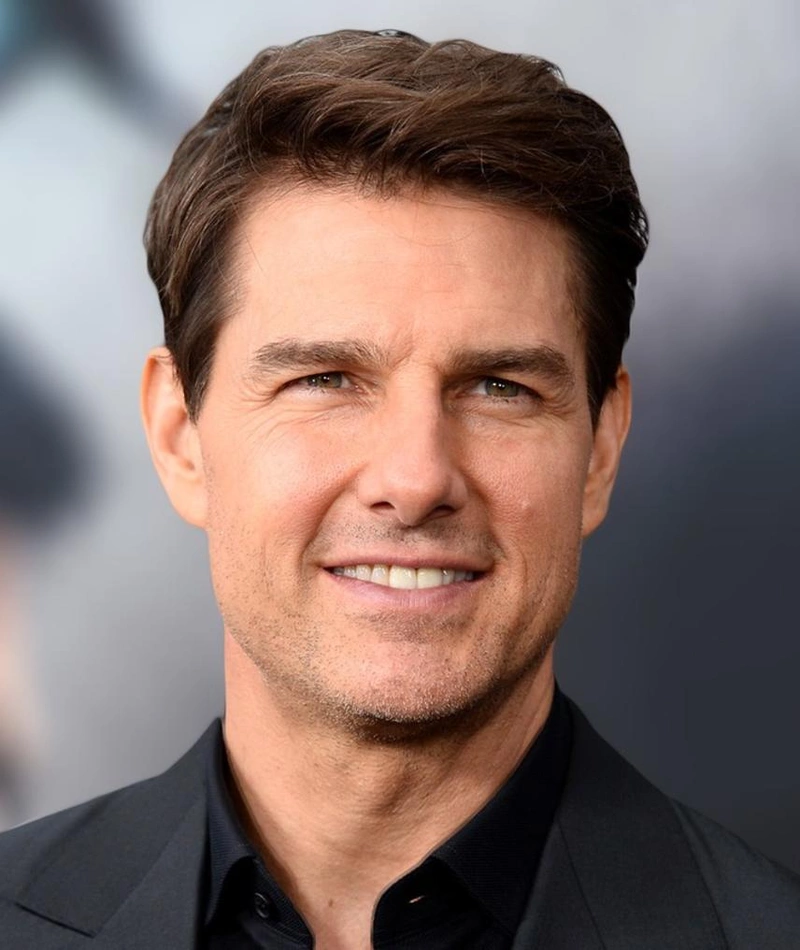

In [16]:
display(PIL.Image.open(tom_cruise_img_path))

In [17]:
# This will work as long as this image is there in the github repo
# This is how we can visualize web images using Ipython.display.Image
img_url = "https://github.com/cookieSensei/AI-tutorials/blob/main/tom.jpg?raw=true"
display(Image(url=img_url))

# Loading image as numpy array

If we wish to create a numpy array of an image for which we have a url, we can use imageio. imageio loads the web image in `RGB` color format

Otherwise we can just simply download the image and use opencv to load the image. opencv loads the image in `BGR` color format

Some times due to too many attempts of downloading files from web, we may face a urlerror meaning, we need to wait a while before downloading web files.

In [18]:


imageio_img_arr = imageio.imread(tom_cruise_img_path)
display(imageio.imread(tom_cruise_img_path))

array([[[ 96, 135, 147],
        [ 94, 133, 144],
        [ 93, 129, 142],
        ...,
        [182, 185, 195],
        [182, 185, 195],
        [182, 185, 195]],

       [[ 96, 135, 147],
        [ 94, 133, 144],
        [ 93, 129, 142],
        ...,
        [182, 185, 195],
        [182, 185, 195],
        [182, 185, 195]],

       [[ 96, 135, 149],
        [ 94, 132, 146],
        [ 93, 129, 142],
        ...,
        [182, 185, 195],
        [182, 185, 195],
        [182, 185, 195]],

       ...,

       [[ 55,  58,  66],
        [ 54,  57,  65],
        [ 56,  59,  67],
        ...,
        [ 46,  48,  52],
        [ 46,  48,  52],
        [ 46,  48,  52]],

       [[ 56,  59,  67],
        [ 56,  59,  67],
        [ 57,  61,  69],
        ...,
        [ 46,  48,  52],
        [ 46,  48,  52],
        [ 46,  48,  52]],

       [[ 55,  58,  66],
        [ 56,  59,  67],
        [ 57,  61,  69],
        ...,
        [ 46,  48,  52],
        [ 46,  48,  52],
        [ 46,  48,  52]]

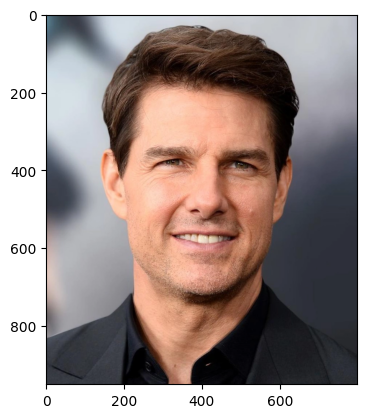

In [19]:
plt.imshow(imageio_img_arr)
plt.show()

In [20]:
tom_cruise_img_path

'resources/tom.jpg'

In [21]:
img_arr = cv2.imread(tom_cruise_img_path)
img_arr

array([[[147, 135,  96],
        [144, 133,  94],
        [142, 129,  93],
        ...,
        [195, 185, 182],
        [195, 185, 182],
        [195, 185, 182]],

       [[147, 135,  96],
        [144, 133,  94],
        [142, 129,  93],
        ...,
        [195, 185, 182],
        [195, 185, 182],
        [195, 185, 182]],

       [[149, 135,  96],
        [146, 132,  94],
        [142, 129,  93],
        ...,
        [195, 185, 182],
        [195, 185, 182],
        [195, 185, 182]],

       ...,

       [[ 66,  58,  55],
        [ 65,  57,  54],
        [ 67,  59,  56],
        ...,
        [ 52,  48,  46],
        [ 52,  48,  46],
        [ 52,  48,  46]],

       [[ 67,  59,  56],
        [ 67,  59,  56],
        [ 69,  61,  57],
        ...,
        [ 52,  48,  46],
        [ 52,  48,  46],
        [ 52,  48,  46]],

       [[ 66,  58,  55],
        [ 67,  59,  56],
        [ 69,  61,  57],
        ...,
        [ 52,  48,  46],
        [ 52,  48,  46],
        [ 52,  48,  46]]

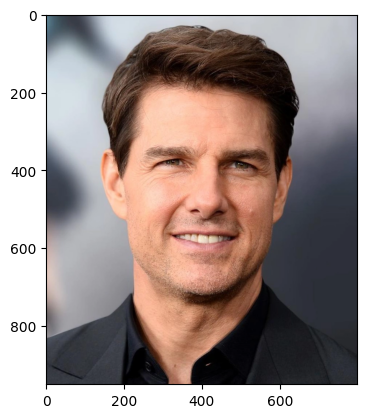

In [22]:
def bgr_rgb(arr):
    arr_rgb = cv2.cvtColor(arr, cv2.COLOR_BGR2RGB)
    plt.imshow(arr_rgb)

bgr_rgb(img_arr)

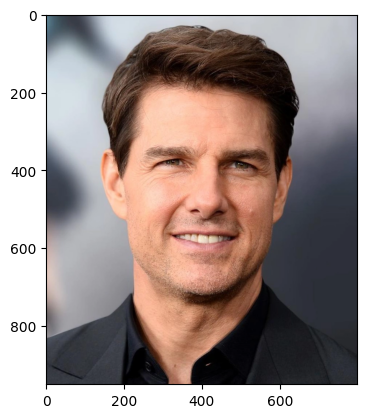

In [23]:
bgr_rgb(img_arr)

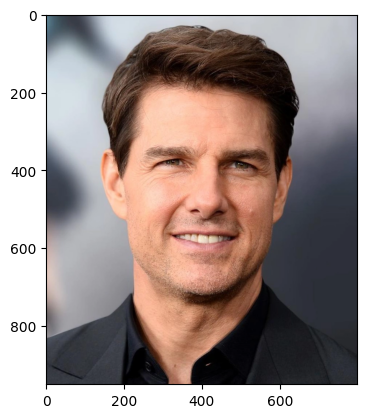

In [24]:
plt.imshow(cv2.cvtColor(img_arr, cv2.COLOR_BGR2RGB))

In [25]:
img_arr.shape

(950, 800, 3)

In [26]:
img_arr[0].shape

(800, 3)

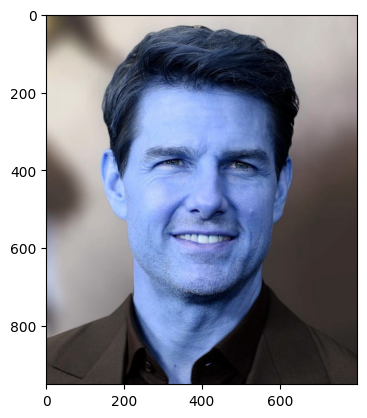

In [27]:
plt.imshow(img_arr);

In [28]:
def cv2_plt(img_arr):
    """Function to visualize an image loaded using opencv.
    
    Parameters:
        img_arr: image array ing BGR format or say image loaded using opencv
    """
    
    img_arr = img_arr.copy()    
    image_rgb = cv2.cvtColor(img_arr, cv2.COLOR_BGR2RGB) 
    
    fig, axes = plt.subplots(1,2)
    
    axes[0].imshow(img_arr)
    axes[0].set_title("opencv loaded Image")
    
    axes[1].imshow(image_rgb)
    axes[1].set_title("RGB Image")

    # plt.show()

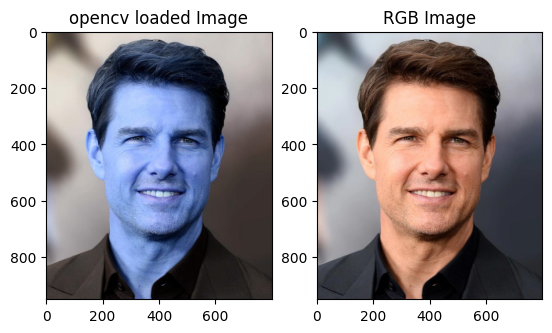

In [29]:
cv2_plt(img_arr)

In [30]:
img_arr

array([[[147, 135,  96],
        [144, 133,  94],
        [142, 129,  93],
        ...,
        [195, 185, 182],
        [195, 185, 182],
        [195, 185, 182]],

       [[147, 135,  96],
        [144, 133,  94],
        [142, 129,  93],
        ...,
        [195, 185, 182],
        [195, 185, 182],
        [195, 185, 182]],

       [[149, 135,  96],
        [146, 132,  94],
        [142, 129,  93],
        ...,
        [195, 185, 182],
        [195, 185, 182],
        [195, 185, 182]],

       ...,

       [[ 66,  58,  55],
        [ 65,  57,  54],
        [ 67,  59,  56],
        ...,
        [ 52,  48,  46],
        [ 52,  48,  46],
        [ 52,  48,  46]],

       [[ 67,  59,  56],
        [ 67,  59,  56],
        [ 69,  61,  57],
        ...,
        [ 52,  48,  46],
        [ 52,  48,  46],
        [ 52,  48,  46]],

       [[ 66,  58,  55],
        [ 67,  59,  56],
        [ 69,  61,  57],
        ...,
        [ 52,  48,  46],
        [ 52,  48,  46],
        [ 52,  48,  46]]

In [31]:
img_arr.shape

(950, 800, 3)

# Single channel image of eight

In [32]:
img_8 = np.zeros((5,5))
img_8

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]])

Trying to create the digit eight

In [33]:
# All the rows and columns 1 and column 3, replace those as value 1
img_8[:, [1,3]] = 1

In [34]:
img_8

array([[0., 1., 0., 1., 0.],
       [0., 1., 0., 1., 0.],
       [0., 1., 0., 1., 0.],
       [0., 1., 0., 1., 0.],
       [0., 1., 0., 1., 0.]])

In [35]:
# For rows 0,2,4 and column 2, replace values as 1
img_8[[0,2,4], 2] = 1

In [36]:
img_8

array([[0., 1., 1., 1., 0.],
       [0., 1., 0., 1., 0.],
       [0., 1., 1., 1., 0.],
       [0., 1., 0., 1., 0.],
       [0., 1., 1., 1., 0.]])

**If the array is integer, plt assumes range 0-255 for pixel brightness values. If the numpy array is in float numpy assumes the pixel values normalized in the range 0-1 where 1 means 255.**

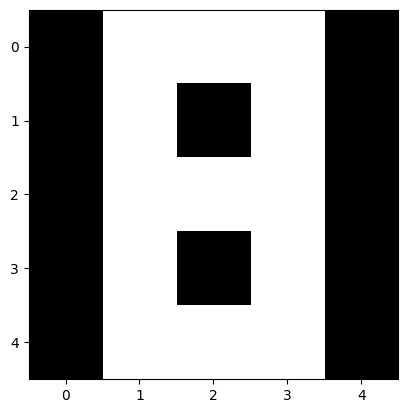

In [37]:
plt.imshow(img_8, cmap=plt.cm.gray);

# Three channel images

In [38]:
# Creating array of 3 row pixel, 2 column pixel, 3 color channel format
np.zeros((3,2,4), dtype=np.int8)

array([[[0, 0, 0, 0],
        [0, 0, 0, 0]],

       [[0, 0, 0, 0],
        [0, 0, 0, 0]],

       [[0, 0, 0, 0],
        [0, 0, 0, 0]]], dtype=int8)

In [39]:
[
    [
        [100, 0, 0],
        [0, 0, 0]],

    [
        [0, 0, 0],
        [0, 0, 0]],
    
    [
        [0, 0, 0],
        [0, 0, 0]]
]

[[[100, 0, 0], [0, 0, 0]], [[0, 0, 0], [0, 0, 0]], [[0, 0, 0], [0, 0, 0]]]

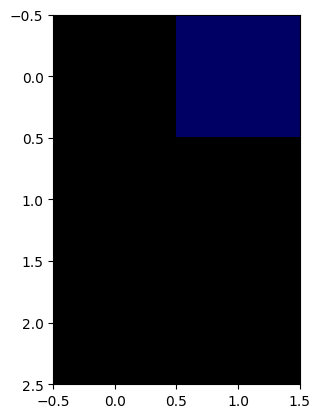

In [40]:
sample_aray = np.array(
[
    [
        [0, 0, 0],
        [0, 0, 100]],

    [
        [0, 0, 0],
        [0, 0, 0]],
    
    [
        [0, 0, 0],
        [0, 0, 0]]
])
plt.imshow(sample_aray)

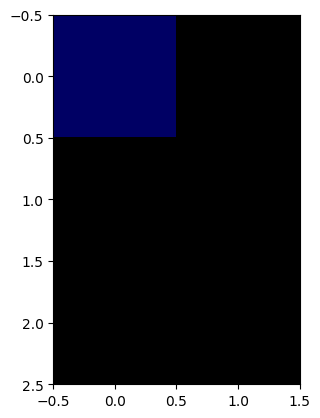

In [41]:
sample_aray = np.array(
[
[
[0, 0, 100],
[0, 0, 0]],

[
[0, 0, 0],
[0, 0, 0]],

[
[0, 0, 0],
[0, 0, 0]]
])

plt.imshow(sample_aray)

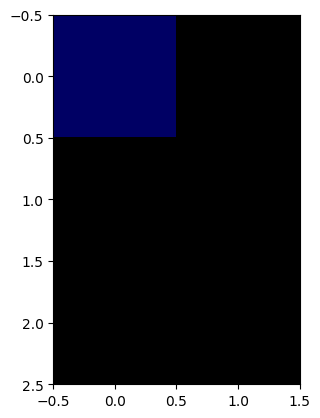

In [42]:
plt.imshow(sample_aray)

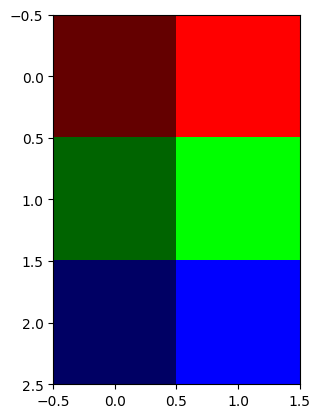

In [43]:
img3c2 = np.array(
    [
        [  #Red, Green, Blue
            [100, 0, 0], # First row, first column pixel
            [255, 0, 0]], # First row, second column pixel
    
        [
            [0, 100, 0], # Second row, first column pixel
            [0, 255, 0]], # Second row, second column pixel
        
        [
            [0, 0, 100], # Third row, first column pixel
            [0, 0, 255]] # Third row, second column pixel
    ]
)

plt.imshow(img3c2)
plt.show()

In [44]:
arr4 = np.zeros((5, 8, 3), dtype=np.int8)
arr4

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=int8)

# Practice assignment

Please fill the third row, first column as `blue`

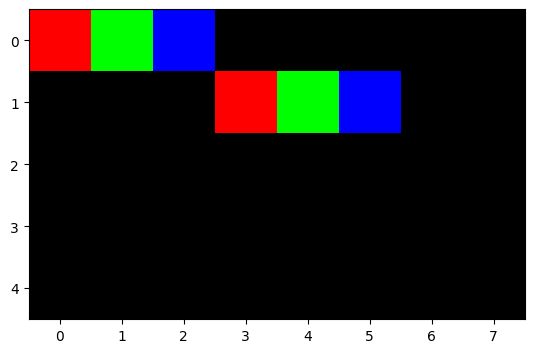

In [45]:
arr4_img = np.array([
    # First row
        [[255, 0, 0],
        [0, 255, 0],
        [0, 0, 255],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],
    
    # Second row
       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [255, 0, 0],
        [0, 255, 0],
        [0, 0, 255],
        [0, 0, 0],
        [0, 0, 0]],

    # Third row
       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

    # Fourth row
       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

    # Fifth row
       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=int)

plt.imshow(arr4_img)
plt.show()

# Solution to practice assignment

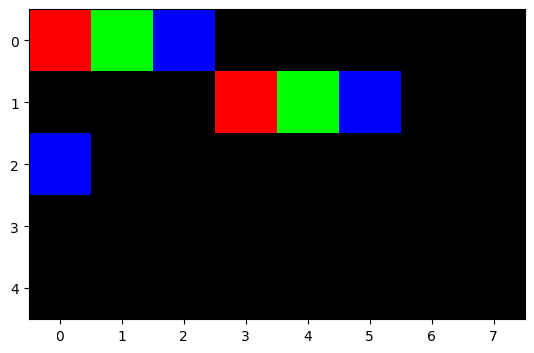

In [46]:
arr5_img = np.array([
    # First row
        [[255, 0, 0],
        [0, 255, 0],
        [0, 0, 255],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],
    
    # Second row
       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [255, 0, 0],
        [0, 255, 0],
        [0, 0, 255],
        [0, 0, 0],
        [0, 0, 0]],

    # Third row
       [[0, 0, 255],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

    # Fourth row
       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

    # Fifth row
       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=int)

plt.imshow(arr5_img)
plt.show()

___

# Write image to disk

Lets learn how to write a loaded image to a directory. Remember we have in this script loaded a lot of images, lets use one of them and save it to our disk.

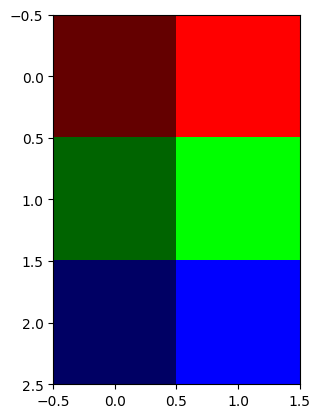

In [47]:
plt.imshow(img3c2)

In [48]:
save_img_path = os.path.join("resources", "saved_image.jpg")
save_img_path

'resources/saved_image.jpg'

In [49]:
if os.path.isfile(save_img_path):
    print(f"file {save_img_path} already exists")
    print(f"Deleting existing copy of {save_img_path}")
    cv2.imwrite(save_img_path, img3c2)
    print(f"Saving the image: {img3c2} \nto path: '{save_img_path}' to disk")
else: 
    cv2.imwrite(save_img_path, img3c2)
    print(f"Saving the image: {img3c2} \nto path: '{save_img_path}' to disk")


file resources/saved_image.jpg already exists
Deleting existing copy of resources/saved_image.jpg
Saving the image: [[[100   0   0]
  [255   0   0]]

 [[  0 100   0]
  [  0 255   0]]

 [[  0   0 100]
  [  0   0 255]]] 
to path: 'resources/saved_image.jpg' to disk


**Opening the image saved to disk, you'll notice how small the image really is. It was total of 6 pixels. Even the color channels were swapped from RGB to BGR**



# Define a function to save Image

In [50]:
def save_image(img_path, image_array):
    
    if os.path.isfile(img_path):
        print(f"file {img_path} already exists")
        print(f"Deleting existing copy of {img_path}")
        cv2.imwrite(img_path, image_array)
        print(f"Saving the image: 'image_array' to path: '{img_path}' to disk")
    else: 
        cv2.imwrite(img_path, image_array)
        print(f"Saving the image: 'image_array' to path: '{img_path}' to disk")


**We loaded tom image using opencv so it is in a BGR format, lets save it as `saved_img2.jpg`**

In [51]:
save_image(os.path.join("resources", "saved_img2.jpg"), img_arr)

file resources/saved_img2.jpg already exists
Deleting existing copy of resources/saved_img2.jpg
Saving the image: 'image_array' to path: 'resources/saved_img2.jpg' to disk


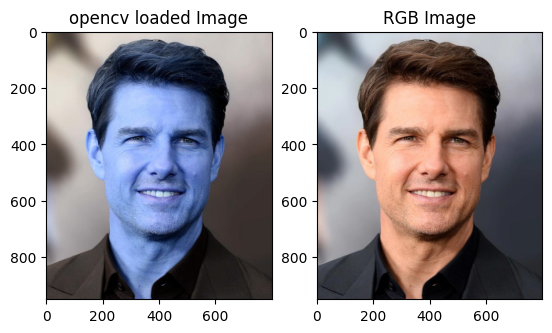

In [52]:
cv2_plt(img_arr)

In [53]:
img_arr.shape

(950, 800, 3)

# Crop an image

In [54]:
os.path.join("resources", "tom.jpg")

'resources/tom.jpg'

In [55]:
img_arr = cv2.imread(os.path.join("resources", "tom.jpg"))

In [56]:
height = img_arr.shape[0]
width = img_arr.shape[1]

In [57]:
arr1 = np.arange(10, 21, 2)
arr1

array([10, 12, 14, 16, 18, 20])

In [58]:
arr1.shape

(6,)

In [59]:
arr1.reshape(-1, 1)

array([[10],
       [12],
       [14],
       [16],
       [18],
       [20]])

In [60]:
arr1[3:5]

array([16, 18])

In [61]:
def cv2_plt(img_arr):
    """Function to visualize an image loaded using opencv.
    
    Parameters:
        img_arr: image array ing BGR format or say image loaded using opencv
    """
    
    img_arr = img_arr.copy()    
    image_rgb = cv2.cvtColor(img_arr, cv2.COLOR_BGR2RGB) 
    plt.imshow(image_rgb)



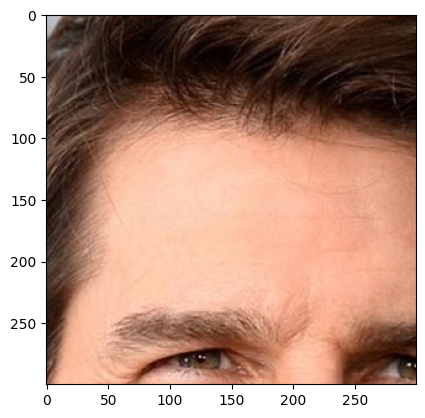

In [62]:
cv2_plt(img_arr[100:400, 200:500])

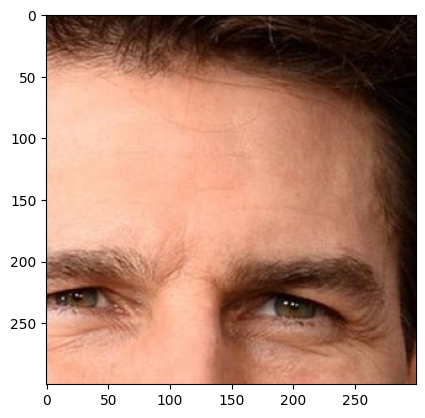

In [63]:
start_row = 150
start_col = 300

end_row = 450
end_col = 600

cropped = img_arr[start_row:end_row, start_col:end_col]
cv2_plt(cropped)

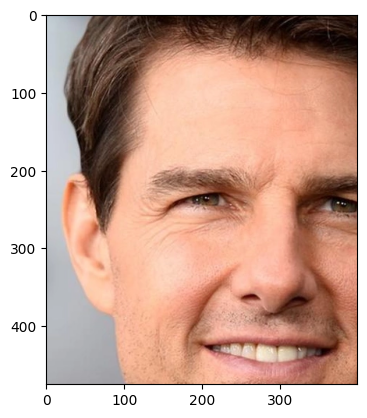

In [64]:


start_row, start_col = int(height*0.15), int(width*0.15)
end_row, end_col = int(height*0.65), int(width*0.65)

cropped = img_arr[start_row:end_row, start_col:end_col]
cv2_plt(cropped)

# Image Convolutions using opencv

In [65]:
def cv2_imshow(img_arr):
    """Function to visualize an image loaded using opencv.
    
    Parameters:
        img_arr: image array ing BGR format or say image loaded using opencv
    """
    
    img_arr = img_arr.copy()    
    image_rgb = cv2.cvtColor(img_arr, cv2.COLOR_BGR2RGB) 

    # plt.figure(figsize=(6,6))
    plt.imshow(image_rgb)
    plt.show()

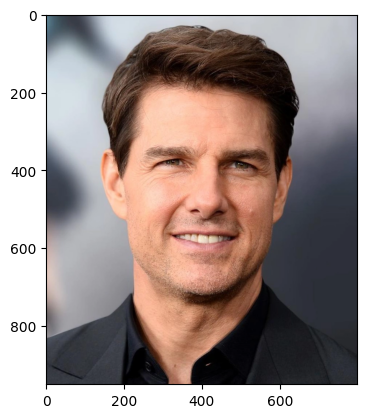

In [66]:
cv2_imshow(img_arr)

# Rotate an image

https://www.geeksforgeeks.org/python-opencv-getrotationmatrix2d-function/

In [67]:
tom_cruise_img_path

'resources/tom.jpg'

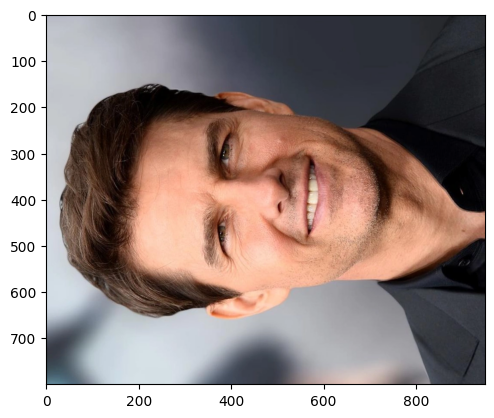

In [68]:
img = cv2.imread(tom_cruise_img_path)

image = cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE)

cv2_plt(image) 

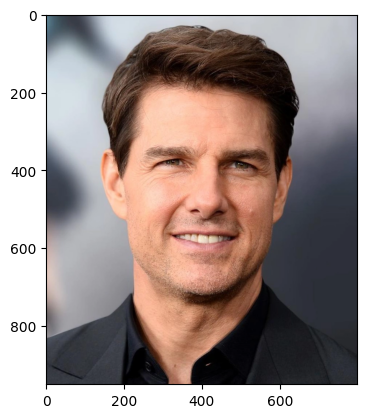

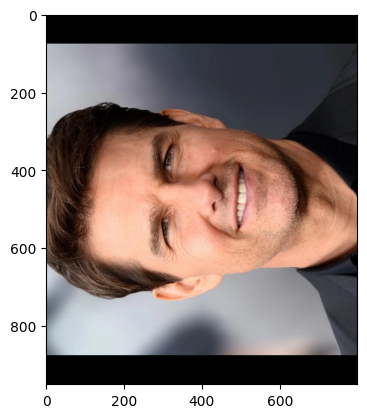

In [69]:
img = cv2.imread(tom_cruise_img_path)

cv2_imshow(img)

height, width = img.shape[0], img.shape[1]

rotate_matrix = cv2.getRotationMatrix2D(
    center=(width/2, height/2), 
    angle=90, 
    scale=1)
 
# rotate the image using cv2.warpAffine  
# 90 degree anticlockwise 
rotated_image = cv2.warpAffine( 
    src=img, M=rotate_matrix, dsize=(width, height)) 

# rotated_image = cv2.warpAffine(img, rotation_matrix, (int(width/2), int(height/2)))

cv2_imshow(rotated_image)

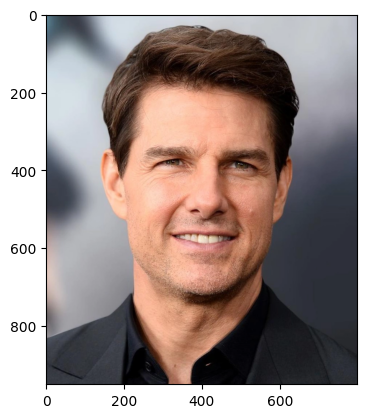

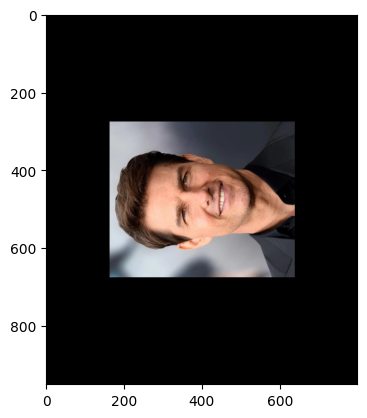

In [70]:
img = cv2.imread(tom_cruise_img_path)

cv2_imshow(img)

height, width = img.shape[0], img.shape[1]

rotate_matrix = cv2.getRotationMatrix2D(
    center=(width/2, height/2), 
    angle=90, 
    scale=0.5)
 
# rotate the image using cv2.warpAffine  
# 90 degree anticlockwise 
rotated_image = cv2.warpAffine( 
    src=img, M=rotate_matrix, dsize=(width, height)) 

cv2_imshow(rotated_image)

# Blur the Image

https://www.geeksforgeeks.org/python-opencv-filter2d-function/

In [71]:
arr1 * 0.11 / 0.11

array([10., 12., 14., 16., 18., 20.])

In [72]:
display(12)
15

12

15

[[0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]]


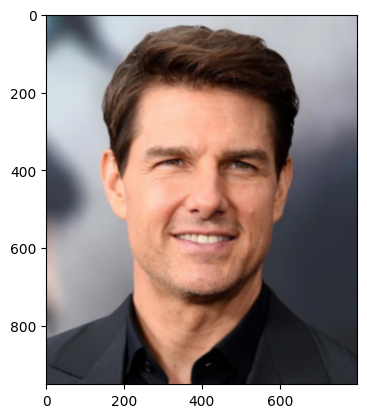

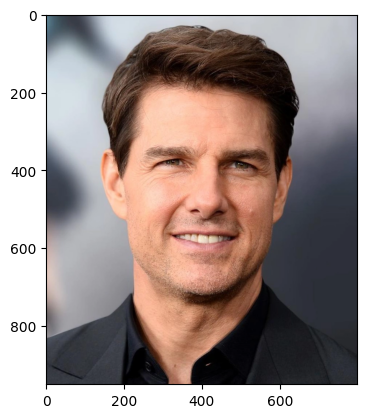

In [73]:
#filter2D(src, dst, ddepth, kernal)

img = cv2.imread(tom_cruise_img_path)

kernal = np.array([
    [1,1,1,1,1],
    [1,1,1,1,1],
    [1,1,1,1,1],
    [1,1,1,1,1],
    [1,1,1,1,1]
])

kernal = kernal/25
print(kernal)

blurred = cv2.filter2D(src=img, ddepth=-1, kernel=kernal)
cv2_plt(blurred)
plt.show()
cv2_plt(img)
plt.show()

# Edge detection

[[-1 -1 -1]
 [-1  8 -1]
 [-1 -1 -1]]


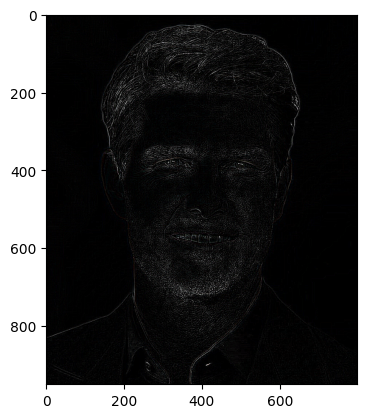

In [74]:
img = cv2.imread(tom_cruise_img_path)

# Creating the kernel(2d convolution matrix) 
# This kernel is specifically used for edge detection
kernel2 = np.array([[-1, -1, -1], 
                    [-1, 8, -1], 
                    [-1, -1, -1]]) 

print(kernel2)

edge = cv2.filter2D(src=img, ddepth=-1, kernel=kernel2)
cv2_imshow(edge)


# Sharpen the Image

[[ 0 -1  0]
 [-1  5 -1]
 [ 0 -1  0]]


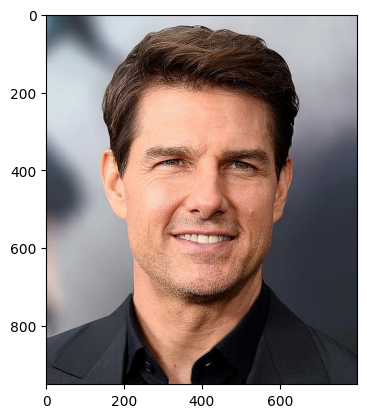

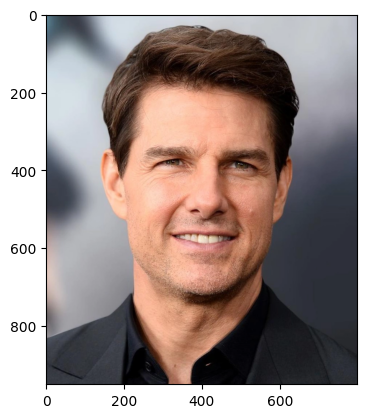

In [75]:
def cv2_imshow(image):
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) 
    plt.imshow(image_rgb)
    plt.show()

img = cv2.imread(tom_cruise_img_path)

kernel3 = np.array([[0, -1, 0], 
                    [-1, 5, -1], 
                    [0, -1, 0]]) 

print(kernel3)

sharp = cv2.filter2D(src=img, ddepth=-1, kernel=kernel3)
cv2_imshow(sharp)
cv2_imshow(img)

# Box blur

[[0.11111111 0.11111111 0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111 0.11111111 0.11111111]]


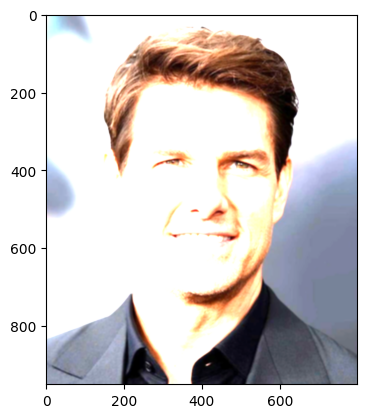

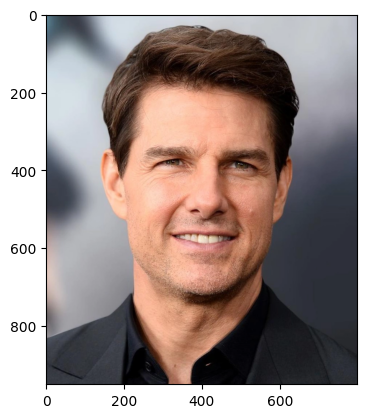

In [76]:
img = cv2.imread(tom_cruise_img_path)

kernel4 = np.ones((5,5))/9

print(kernel4)

box_blur = cv2.filter2D(src=img, ddepth=-1, kernel=kernel4)
cv2_imshow(box_blur)
cv2_imshow(img)

# Image Pyramids

https://www.geeksforgeeks.org/image-pyramid-using-opencv-python/

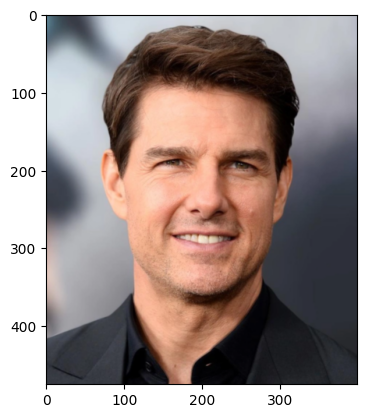

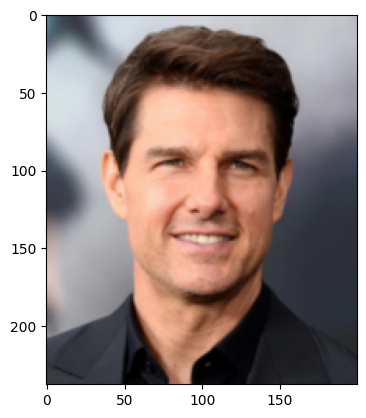

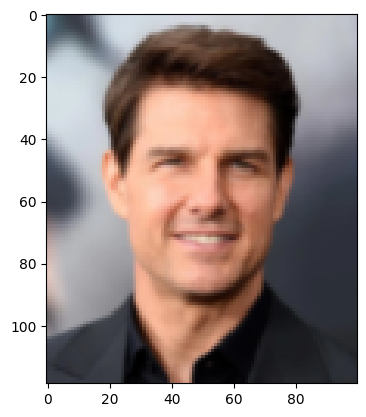

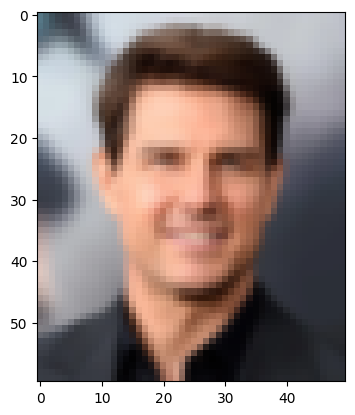

In [77]:
img = cv2.imread(tom_cruise_img_path)

layer = img.copy() 

# Scaling down the image

for i in range(4): 
    # using pyrDown() function 
    layer = cv2.pyrDown(layer) 
  
    cv2_imshow(layer) 
    

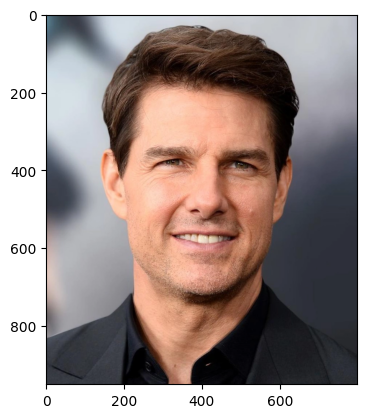

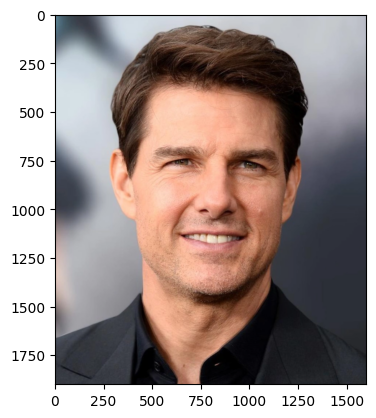

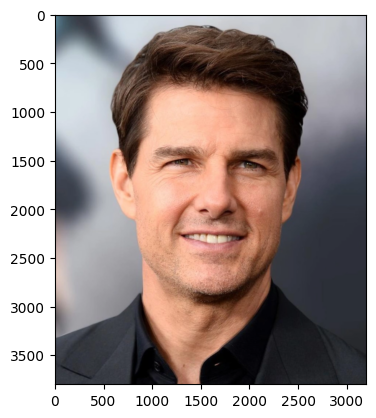

In [78]:
img = cv2.imread(tom_cruise_img_path)

cv2_imshow(img)

layer = img.copy() 

# Scaling down the image

for i in range(2): 
    # using pyrUp() function 
    layer = cv2.pyrUp(layer) 
  
    cv2_imshow(layer) 
    

`

# Canny Edge filter in OpenCV

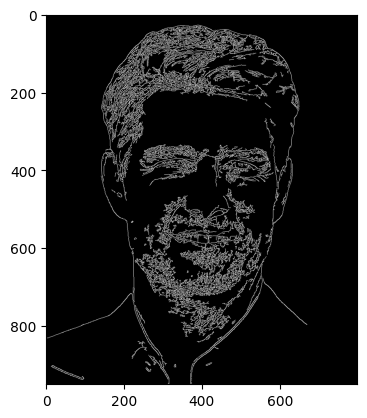

In [79]:

img = cv2.imread(tom_cruise_img_path)

# Setting parameter values 
t_lower = 50  # Lower Threshold 
t_upper = 150  # Upper threshold 


##################### Canny(image, T_lower, T_upper, aperture_size, L2Gradient)

# Applying the Canny Edge filter 
edge = cv2.Canny(img, t_lower, t_upper) 

cv2_imshow(edge)

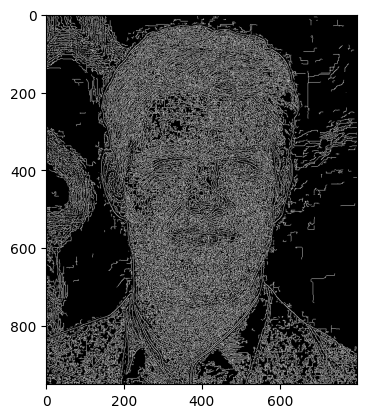

In [80]:
img = cv2.imread(tom_cruise_img_path)

canny_img = cv2.Canny(img, 10, 20)
cv2_imshow(canny_img)

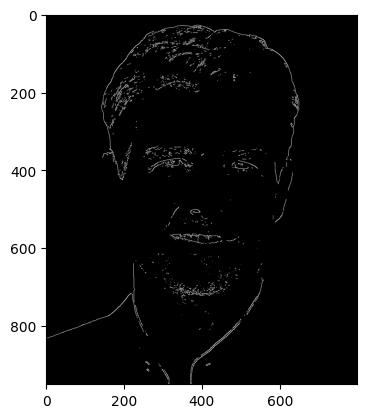

In [81]:
img = cv2.imread(tom_cruise_img_path)

canny_img = cv2.Canny(img, 200, 220)
cv2_imshow(canny_img)

# Thank You

I hope your understanding of working with images have gotten better. Happy Learning.